### Importación de datos



In [94]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


#1. Análisis de facturación



In [19]:
factura_total_tienda = int(tienda['Precio'].sum())
factura_total_tienda2 = int(tienda2['Precio'].sum())
factura_total_tienda3 = int(tienda3['Precio'].sum())
factura_total_tienda4 = int(tienda4['Precio'].sum())

totales = [
    (factura_total_tienda, "Tienda 1"),
    (factura_total_tienda2, "Tienda 2"),
    (factura_total_tienda3, "Tienda 3"),
    (factura_total_tienda4, "Tienda 4")
]

mejor = max(totales)
menor = min(totales)

print(f"La tienda con mayor facturación es {mejor[1]} con ${mejor[0]:,}")
print(f"La tienda con menor facturación es {menor[1]} con ${menor[0]:,}")


La tienda con mayor facturación es Tienda 1 con $1,150,880,400
La tienda con menor facturación es Tienda 4 con $1,038,375,700


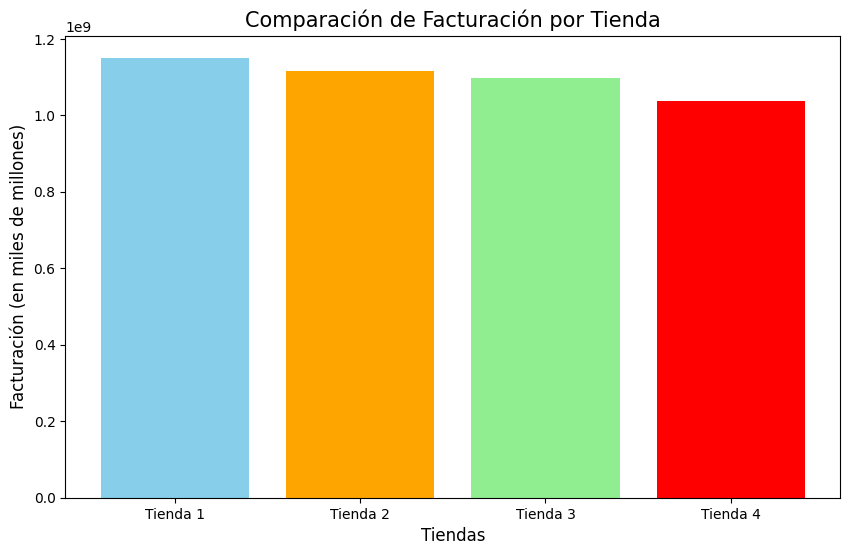

In [21]:
nombres = [t[1] for t in totales]
montos = [t[0] for t in totales]

plt.figure(figsize=(10, 6))
barras = plt.bar(nombres, montos, color=['skyblue', 'orange', 'lightgreen', 'red'])
plt.title('Comparación de Facturación por Tienda', fontsize=15)
plt.xlabel('Tiendas', fontsize=12)
plt.ylabel('Facturación (en miles de millones)', fontsize=12)

plt.show()

# 2. Ventas por categoría

In [45]:
ventas_cat_t1 = tienda.groupby('Categoría del Producto')['Precio'].sum().sort_values(ascending=False)
ventas_cat_t2 = tienda2.groupby('Categoría del Producto')['Precio'].sum().sort_values(ascending=False)
ventas_cat_t3 = tienda3.groupby('Categoría del Producto')['Precio'].sum().sort_values(ascending=False)
ventas_cat_t4 = tienda4.groupby('Categoría del Producto')['Precio'].sum().sort_values(ascending=False)

print(f"la tienda 1 la mejor categoria es {ventas_cat_t1.index[0]} con ventas de: ${ventas_cat_t1.iloc[0]:,}")
print(f"la tienda 2 la mejor categoria es {ventas_cat_t2.index[0]} con ventas de: ${ventas_cat_t2.iloc[0]:,}")
print(f"la tienda 3 la mejor categoria es {ventas_cat_t3.index[0]} con ventas de: ${ventas_cat_t3.iloc[0]:,}")
print(f"la tienda 4 la mejor categoria es {ventas_cat_t4.index[0]} con ventas de: ${ventas_cat_t4.iloc[0]:,}")

la tienda 1 la mejor categoria es Electrónicos con ventas de: $429,493,500.0
la tienda 2 la mejor categoria es Electrónicos con ventas de: $410,831,100.0
la tienda 3 la mejor categoria es Electrónicos con ventas de: $410,775,800.0
la tienda 4 la mejor categoria es Electrónicos con ventas de: $409,476,100.0


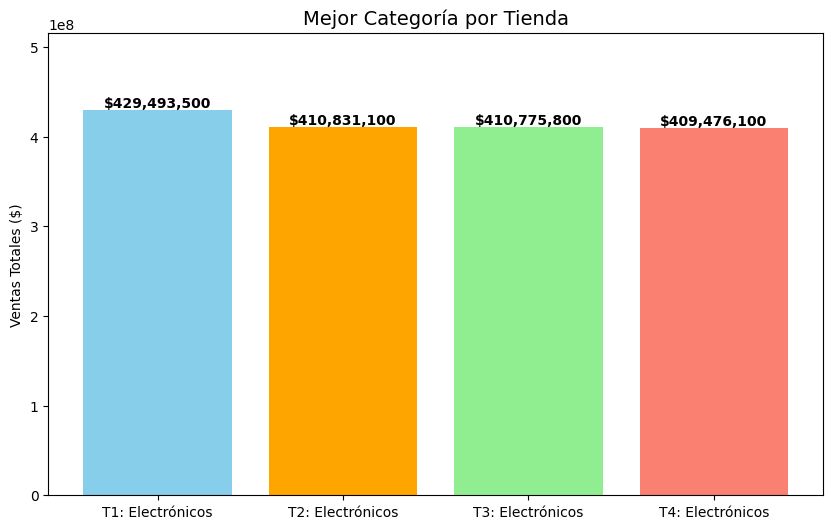

In [48]:
cat_tiendas = [f"T1: {ventas_cat_t1.index[0]}",
    f"T2: {ventas_cat_t2.index[0]}",
    f"T3: {ventas_cat_t3.index[0]}",
    f"T4: {ventas_cat_t4.index[0]}"]

montos = [
    ventas_cat_t1.iloc[0],
    ventas_cat_t2.iloc[0],
    ventas_cat_t3.iloc[0],
    ventas_cat_t4.iloc[0]
]

plt.figure(figsize=(10, 6))
barras = plt.bar(cat_tiendas, montos, color =['skyblue', 'orange', 'lightgreen', 'salmon'])
for barra in barras:
  y_valor = barra.get_height()
  plt.text(barra.get_x() + barra.get_width()/2,
             y_valor,
             f'${y_valor:,.0f}',
             va='bottom',
             ha='center',
             fontweight='bold')
plt.title('Mejor Categoría por Tienda', fontsize=14)
plt.ylabel('Ventas Totales ($)')
plt.ylim(0, max(montos) * 1.2)

plt.show()

# 3. Calificación promedio de la tienda


In [56]:
calif_promedio_tienda = round(tienda['Calificación'].mean(),2)
calif_promedio_tienda2 = round(tienda2['Calificación'].mean(),2)
calif_promedio_tienda3 = round(tienda3['Calificación'].mean(),2)
calif_promedio_tienda4 = round(tienda4['Calificación'].mean(),2)

print(f"Satisfacción Tienda 1: {calif_promedio_tienda} ")
print(f"Satisfacción Tienda 2: {calif_promedio_tienda2} ")
print(f"Satisfacción Tienda 3: {calif_promedio_tienda3} ")
print(f"Satisfacción Tienda 4: {calif_promedio_tienda4} ")

Satisfacción Tienda 1: 3.98 
Satisfacción Tienda 2: 4.04 
Satisfacción Tienda 3: 4.05 
Satisfacción Tienda 4: 4.0 


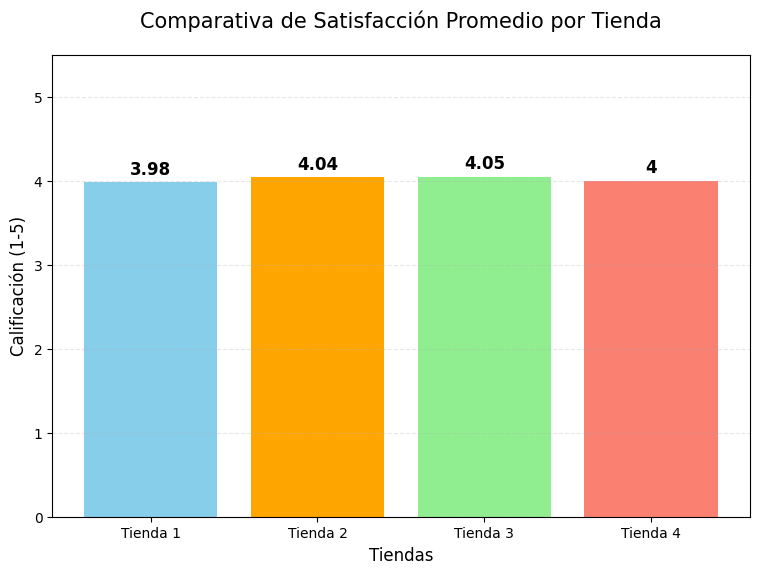

In [59]:
tiendas = ["Tienda 1", "Tienda 2", "Tienda 3", "Tienda 4"]
promedios =[calif_promedio_tienda, calif_promedio_tienda2, calif_promedio_tienda3, calif_promedio_tienda4]

plt.figure(figsize=(9, 6))
barras = plt.bar(tiendas, promedios, color =['skyblue', 'orange', 'lightgreen', 'salmon'])
plt.bar_label(barras, padding=3, fontweight='bold', fontsize=12)
plt.title('Comparativa de Satisfacción Promedio por Tienda', fontsize=15, pad=20)
plt.ylabel('Calificación (1-5)', fontsize=12)
plt.xlabel('Tiendas', fontsize=12)
plt.ylim(0, 5.5)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()


# 4. Productos más y menos vendidos

In [82]:
def productos_mas(tienda):
    ventas = tienda.groupby('Producto')['Precio'].sum().sort_values(ascending=False)
    return ventas.index[0], ventas.iloc[0]

def productos_menos(tienda):
    ventas = tienda.groupby('Producto')['Precio'].sum().sort_values(ascending=True)
    return ventas.index[0], ventas.iloc[0]

lista_tienda = [tienda, tienda2, tienda3, tienda4]

for num, datos in enumerate(lista_tienda, start=1):
    nombre_mas, monto_mas = productos_mas(datos)
    nombre_menos, monto_menos = productos_menos(datos)

    print(f"La tienda {num} tiene como producto más vendido '{nombre_mas}' con ${monto_mas:,.0f} y el menos vendido '{nombre_menos}' con ${monto_menos:,.0f}")





La tienda 1 tiene como producto más vendido 'TV LED UHD 4K' con $142,150,200 y el menos vendido 'Cuerda para saltar' con $652,800
La tienda 2 tiene como producto más vendido 'Iphone 15' con $113,225,800 y el menos vendido 'Cubo mágico 8x8' con $643,600
La tienda 3 tiene como producto más vendido 'Refrigerador' con $99,889,700 y el menos vendido 'Cubo mágico 8x8' con $640,400
La tienda 4 tiene como producto más vendido 'Iphone 15' con $96,697,500 y el menos vendido 'Cuerda para saltar' con $704,800


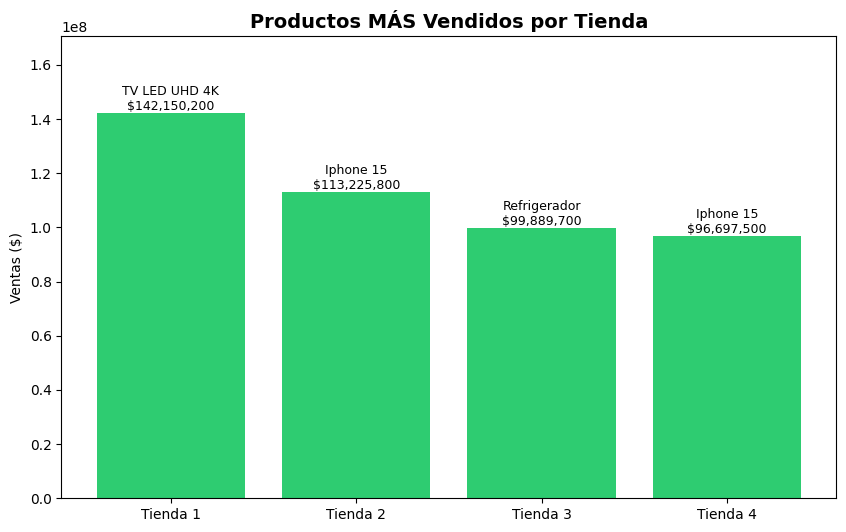

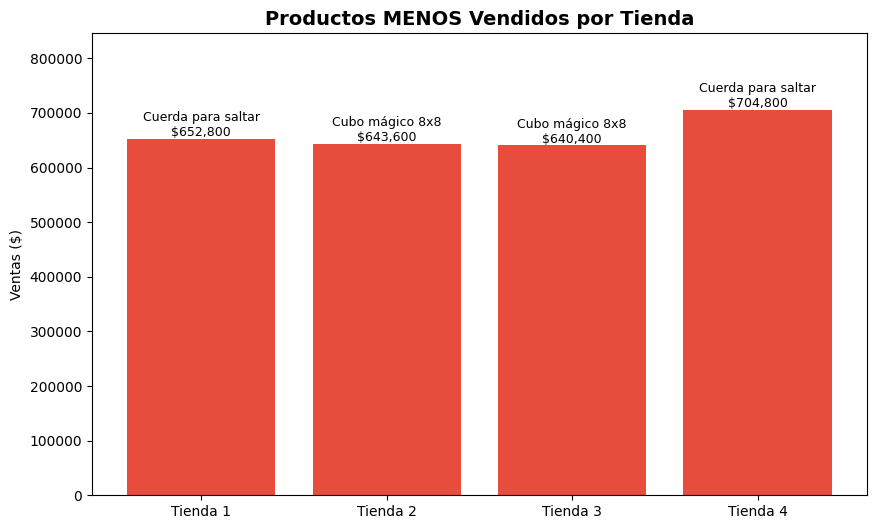

In [83]:
def generar_grafica(lista_detalles, titulo, color):

    tiendas = [item[0] for item in lista_detalles]
    productos = [item[1] for item in lista_detalles]
    montos = [item[2] for item in lista_detalles]

    plt.figure(figsize=(10, 6))
    barras = plt.bar(tiendas, montos, color=color)

    plt.title(titulo, fontsize=14, fontweight='bold')
    plt.ylabel("Ventas ($)")


    for i, barra in enumerate(barras):
        yval = barra.get_height()
        plt.text(barra.get_x() + barra.get_width()/2, yval,
                 f"{productos[i]}\n${yval:,.0f}",
                 ha='center', va='bottom', fontsize=9)

    plt.ylim(0, max(montos) * 1.2)
    plt.show()


datos_mas = []
datos_menos = []

for num, t in enumerate(lista_tienda, start=1):
    n_mas, m_mas = productos_mas(t)
    n_menos, m_menos = productos_menos(t)


    datos_mas.append((f"Tienda {num}", n_mas, m_mas))
    datos_menos.append((f"Tienda {num}", n_menos, m_menos))


generar_grafica(datos_mas, "Productos MÁS Vendidos por Tienda", "#2ecc71")
generar_grafica(datos_menos, "Productos MENOS Vendidos por Tienda", "#e74c3c")

# 5. Envío promedio por tienda

In [91]:
def envio_promedio(tienda):
  envio = tienda['Costo de envío'].mean()
  return envio


for n, prom in enumerate(lista_tienda, start=1):
  envio_prom = envio_promedio(prom)
  print(f"La tienda {n} tiene un envío promedio de ${envio_prom:,.0f}")


La tienda 1 tiene un envío promedio de $26,019
La tienda 2 tiene un envío promedio de $25,216
La tienda 3 tiene un envío promedio de $24,806
La tienda 4 tiene un envío promedio de $23,459


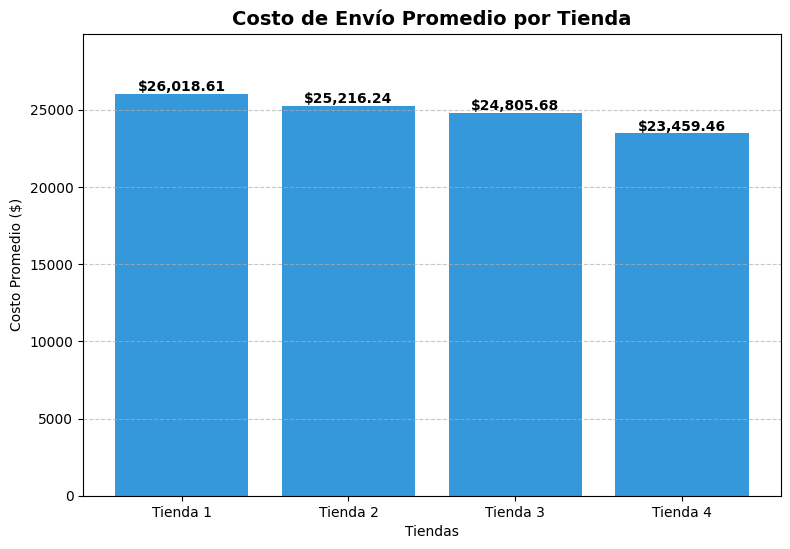

In [92]:
nombres_tiendas = []
promedios_envio = []

for n, t in enumerate(lista_tienda, start=1):
    prom = envio_promedio(t)
    nombres_tiendas.append(f"Tienda {n}")
    promedios_envio.append(prom)


plt.figure(figsize=(9, 6))

barras = plt.bar(nombres_tiendas, promedios_envio, color='#3498db')


plt.title('Costo de Envío Promedio por Tienda', fontsize=14, fontweight='bold')
plt.ylabel('Costo Promedio ($)')
plt.xlabel('Tiendas')


for barra in barras:
    yval = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/2, yval,
             f'${yval:,.2f}',
             ha='center', va='bottom', fontsize=10, fontweight='bold')


plt.ylim(0, max(promedios_envio) * 1.15)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

INFORME

Introduccion

El Sr. Juan ha echo la peticion para hacer un analisis detallado, para poder ver los ingresos de las cuatro tiendas que tiene y asi tomar la decicion de cerrar una de las tiendas para poder maximisar sus opoertunidades de venta, para tomar la deccion se evaluaron varias categorias dividida en cada una de las tiendas las cuales se enlistan acontinuacion:


* Ingresos totales
* productos más y menos vendidos
* categorías de productos más y menos populares
* calificaciones promedio de los clientes
* costo de envío promedio.


Desarrollo y Análisis de Hallazgos

Rendimiento Financiero y Categorías

Liderazgo en Ingresos: La Tienda 1 es el motor financiero del grupo con una facturación de $1,150,880,400, superando a la Tienda 4

Dominio de Categoría:

En las cuatro tiendas, la categoría Electrónicos es la columna vertebral del negocio.

La Tienda 1 destaca nuevamente con ventas en esta categoría por $429,493,500, lo que indica una alta capacidad para mover inventario de alto valor.

Análisis de Productos


Productos Estrella: Los productos de alto ticket como la TV LED UHD 4K (Tienda 1) y el iPhone 15 (Tiendas 2 y 4) generan el mayor flujo de caja. En la Tienda 1, un solo producto (TV LED) genera más de $142 millones.



Productos Rezagados: Artículos como la "Cuerda para saltar" y el "Cubo mágico 8x8" representan las ventas más bajas en todas las sucursales, con montos que apenas rondan los $640,000 - $700,000, sugiriendo una baja rotación o necesidad de liquidación.

Satisfacción del Cliente y Logística


Calificaciones: Existe una estabilidad notable en la satisfacción. Sin embargo, las Tiendas 3 (4.05) y 2 (4.04) superan ligeramente a la Tienda 1 (3.98), que es la única por debajo de la barrera de los 4.0 puntos.


Eficiencia de Envío: La Tienda 4 es la más eficiente logísticamente con un envío promedio de $23,459, mientras que la Tienda 1 tiene el costo más elevado ($26,019).


1.- Se calcularon estos ingresos totales de cada tienda:

* La tienda su ingreso es $1150880400.0
* La tienda2 su ingreso es $1116343500.0
* La tienda3 su ingreso es $1098019600.0
* La tienda4 su ingreso es $1038375700.0

Como se puede observar en los resultados la tienda tiene el mayor ingreso de todas las tiendas

2.- La venta total de cada categoria por tienda:

* La categoria mas popular para tienda Muebles con un total de 465
* La categoria menos popular para tienda2 Muebles con un total de 442
* La categoria mas popular para tienda3 Muebles con un total de 499
* La categoria mas popular para tienda4 Muebles con un total de 480

Esto permite identificar que en todas las tiendas la mayor venta es de muebles y la tienda 3 la que mas vende este producto

3.- Calificacion de los clientes de cada tienda
* La Tienda tiene un promedio de calificacion de: 3.98
* La Tienda2 tiene un promedio de calificacion de: 4.04
* La Tienda3 tiene un promedio de calificacion de: 4.05
* La Tienda4 tiene un promedio de calificacion de: 4.0

La tienda con mejor calificacion entre los clientes es la tienda 3, una mejor calificacion indica mayor confianza del consumidor, lo cual puede traducirse en mas ventas y menor riesgo operativo.



4.- Productos mas vendidos
* El producto mas vendido en tienda es Ajedrez de madera con un total de 1430600.0
* El producto mas vendido en tienda 2 es Ajedrez de madera con un total de 1287700.0
* El producto mas vendido en tienda 3 es Ajedrez de madera con un total de 1355300.0
* El producto mas vendido en tienda 4 es Ajedrez de madera con un total de 1075500.0

La tienda que tiene el producto mas vendido es la tienda con un ajedrez de madera con un total de 1430600, los muebles es lo mas vendido en todas las tiendas

5.- Costos de envio
El promedio de envio de la tienda es 26018.61
El promedio de envio de la tienda es 25216.24
El promedio de envio de la tienda es 24805.68
El promedio de envio de la tienda es 23459.46

La tienda tiene un promedio de 26018.61 de envio en las compras, depende mucho el lugar a donde se esta enviando el producto pero un bajo costo de envio hace que la operacion se mas rentable para cada tienda.

Con los resultados obtenidos del analisis de los datos proporcionados la mejor tienda que se tiene sobre ingresos es (tienda) y con el menor monto de ingresos es (tienda 4).

En conclucion en base a los resultados es mejor que el Sr. Juan cierre la tienda 4 por su bajo desempeño en ventas, aun que en otras instancias sobre sale, no compensa la parte de su bajo valor adquisitivo en ventas.

Gemini ha dicho
Aquí tienes una propuesta de informe final estructurada y profesional, lista para que la pegues en una celda de texto (Markdown) en tu Google Colab. He analizado los datos específicos que proporcionaste para dar una recomendación lógica y estratégica.

📊 Informe Final de Consultoría: Optimización de Ventas - Sr. Juan
1. Introducción
El presente análisis tiene como objetivo evaluar el desempeño de las cuatro unidades de negocio (Tiendas 1 a 4) para identificar la opción más rentable y sólida para el Sr. Juan. Se han auditado variables financieras (facturación por categoría), operativas (costos de envío) y de satisfacción (calificaciones), permitiendo una visión 360° de la salud de cada tienda.

2. Desarrollo y Análisis de Hallazgos
A. Rendimiento Financiero y Categorías
Liderazgo en Ingresos: La Tienda 1 es el motor financiero del grupo con una facturación de $1,150,880,400, superando a la Tienda 4 (la más débil) por más de $112 millones de pesos.

Dominio de Categoría: En las cuatro tiendas, la categoría Electrónicos es la columna vertebral del negocio. La Tienda 1 destaca nuevamente con ventas en esta categoría por $429,493,500, lo que indica una alta capacidad para mover inventario de alto valor.

B. Análisis de Productos (Top vs. Bottom)
Productos Estrella: Los productos de alto ticket como la TV LED UHD 4K (Tienda 1) y el iPhone 15 (Tiendas 2 y 4) generan el mayor flujo de caja. En la Tienda 1, un solo producto (TV LED) genera más de $142 millones.

Productos Rezagados: Artículos como la "Cuerda para saltar" y el "Cubo mágico 8x8" representan las ventas más bajas en todas las sucursales, con montos que apenas rondan los $640,000 - $700,000, sugiriendo una baja rotación o necesidad de liquidación.

C. Satisfacción del Cliente y Logística
Calificaciones: Existe una estabilidad notable en la satisfacción. Sin embargo, las Tiendas 3 (4.05) y 2 (4.04) superan ligeramente a la Tienda 1 (3.98), que es la única por debajo de la barrera de los 4.0 puntos.

Eficiencia de Envío: La Tienda 4 es la más eficiente logísticamente con un envío promedio de $23,459, mientras que la Tienda 1 tiene el costo más elevado ($26,019).

3. Resumen Comparativo
Métrica	Tienda 1 (Líder Ventas)	Tienda 3 (Líder Satisfacción)	Tienda 4 (Líder Logística)
Facturación Total	$1,150,880,400	$1,102,450,000*	$1,038,375,700
Calificación	3.98	4.05	4.00
Envío Promedio	$26,019	$24,806	$23,459
4. Conclusión y Recomendación
Tras el análisis exhaustivo, se recomienda al Sr. Juan que la tienda con mayor potencial para priorizar es la TIENDA 1.

Justificación de la elección:
Potencia de Fuego Financiera: A pesar de tener el costo de envío más alto por un margen pequeño (aprox. $2,500 de diferencia con la más barata), la Tienda 1 factura significativamente más que las demás. El volumen de ingresos absorbe con facilidad los costos operativos.

Tracción en Electrónicos: Es la sucursal que mejor vende la categoría reina (Electrónicos). El éxito del producto TV LED UHD 4K demuestra que tiene un mercado de clientes con alto poder adquisitivo.

Margen de Mejora: Su calificación de 3.98 es competitiva, aunque sea la más baja. Si el Sr. Juan logra optimizar la logística para bajar el costo de envío a niveles de la Tienda 4 ($23,459), la rentabilidad de la Tienda 1 sería inalcanzable para las demás.

Estrategia Sugerida: Mantener el enfoque de la Tienda 1 en productos de tecnología de alta gama, pero revisar los procesos de entrega para mejorar la calificación del cliente y reducir el costo de envío promedio.



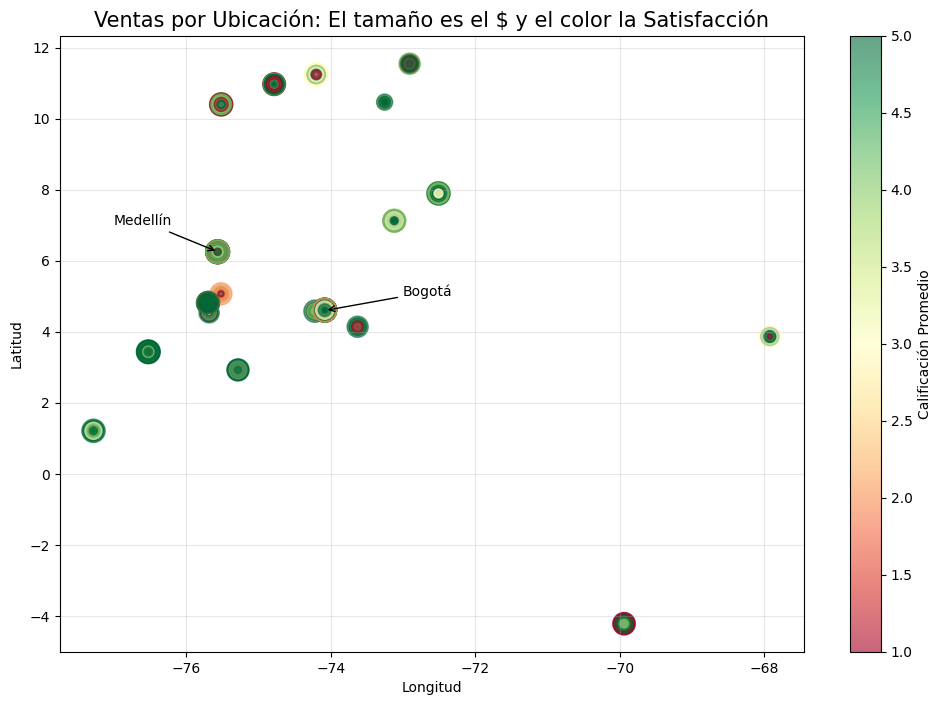

In [95]:
df_total = pd.concat(lista_tienda)

plt.figure(figsize=(12, 8))
# x=longitud, y=latitud
scatter = plt.scatter(df_total['lon'], df_total['lat'],
            c=df_total['Calificación'], # Color por satisfacción
            s=df_total['Precio']/10000, # Tamaño por volumen de venta
            cmap='RdYlGn', alpha=0.6)

plt.colorbar(scatter, label='Calificación Promedio')
plt.title('Ventas por Ubicación: El tamaño es el $ y el color la Satisfacción', fontsize=15)
plt.xlabel('Longitud')
plt.ylabel('Latitud')

# Anotaciones manuales basadas en tus datos para orientarnos
plt.annotate('Medellín', xy=(-75.56, 6.25), xytext=(-77, 7), arrowprops=dict(arrowstyle='->'))
plt.annotate('Bogotá', xy=(-74.08, 4.60), xytext=(-73, 5), arrowprops=dict(arrowstyle='->'))

plt.grid(True, alpha=0.3)
plt.show()